# Milestone 1: Data Collection & Preprocessing
## Intelligent Support Ticket Classification with RAG

This notebook performs:
- Data loading
- Data validation
- Exploratory Data Analysis (EDA)
- Text merging
- Text cleaning
- Preparation of cleaned dataset for modeling


### 1 — Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords


### 2 — Load Dataset

In [2]:
data = pd.read_csv("../data/processed/tickets_cleaned.csv")

print("Dataset Shape:", data.shape)
data.head()


Dataset Shape: (2831631, 3)


,clean_text,Issue_Category,source
0,hours operation individual hi support headquar...,General Inquiry,ticket
1,data syncing card hi support application crash...,Technical,ticket
2,2fa issues question hi support upgrade enterpr...,Account,ticket
3,login failed let hi support dashboard loading ...,Technical,ticket
4,refund status attention hi support trying upda...,Billing,ticket


### 3 — Data Overview

In [3]:
data.info()
data.isnull().sum()
print("Duplicate rows:", data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2831631 entries, 0 to 2831630
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   clean_text      object
 1   Issue_Category  object
 2   source          object
dtypes: object(3)
memory usage: 64.8+ MB
Duplicate rows: 86069


### Dataset contains:
- 20,000 support tickets
- 12 columns
- No missing values
- No duplicate rows


### 4 — Drop Irrelevant Columns

#### Removing columns not required for text classification:
- Customer_Name
- Customer_Email
- Assigned_Agent
- Submission_Date
- Ticket_ID
- Satisfaction_Score


In [ ]:
cols_to_drop = [
    "Customer_Name",
    "Customer_Email",
    "Assigned_Agent",
    "Submission_Date",
    "Ticket_ID",
    "Satisfaction_Score"
]

data = data.drop(columns=cols_to_drop)

print("New Shape:", data.shape)


### 5 — Merge Text Columns

#### Combining Ticket_Subject and Ticket_Description
Creating a unified text field for NLP processing.


In [ ]:
data["full_text"] = (
    data["Ticket_Subject"].astype(str) + " " +
    data["Ticket_Description"].astype(str)
)

data.head()


KeyError: 'Ticket_Subject'

### 6 — Text Length Analysis (EDA)

In [ ]:
data["text_length"] = data["full_text"].apply(lambda x: len(str(x)))

plt.figure()
data["text_length"].hist()
plt.title("Distribution of Ticket Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


KeyError: 'full_text'

### 7 — Class Distribution

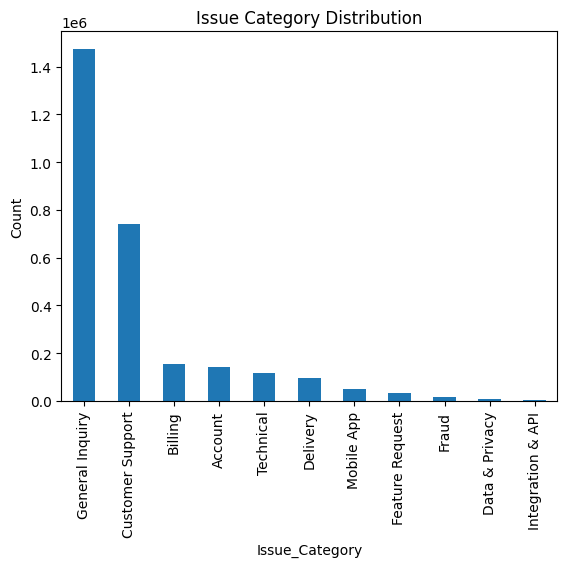

In [ ]:
plt.figure()
data["Issue_Category"].value_counts().plot(kind="bar")
plt.title("Issue Category Distribution")
plt.ylabel("Count")
plt.show()


### 8 — Text Cleaning

#### Text Cleaning
- Lowercasing
- Removing special characters
- Removing stopwords


In [ ]:
nltk.download("stopwords")
stop = set(stopwords.words("english"))

def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r"[^a-zA-Z0-9\s]", "", txt)
    txt = " ".join([w for w in txt.split() if w not in stop])
    return txt

data["clean_text"] = data["full_text"].apply(clean_text)

data.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hashe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,full_text,text_length,clean_text
0,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,"Hours of operation - Individual Hi Support, Wh...",112,hours operation individual hi support headquar...
1,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,"Data not syncing - Card Hi Support, The applic...",122,data syncing card hi support application crash...
2,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,"2FA issues - Question Hi Support, How do I upg...",108,2fa issues question hi support upgrade enterpr...
3,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,41,"Login failed - Let Hi Support, The dashboard i...",119,login failed let hi support dashboard loading ...
4,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,40,"Refund status - Attention Hi Support, I have b...",124,refund status attention hi support trying upda...


### 9 — Final Dataset Selection

#### Keeping only necessary columns for modeling
- clean_text
- Issue_Category (Target)


In [ ]:
final_data = data[["clean_text", "Issue_Category"]]

final_data.head()


,clean_text,Issue_Category
0,hours operation individual hi support headquar...,General Inquiry
1,data syncing card hi support application crash...,Technical
2,2fa issues question hi support upgrade enterpr...,Account
3,login failed let hi support dashboard loading ...,Technical
4,refund status attention hi support trying upda...,Billing


### 10 — Save Cleaned Dataset

#### Saving Cleaned Dataset

After preprocessing and cleaning the support tickets,
we save the cleaned corpus for further modeling and RAG pipeline development.

The cleaned dataset will be stored in:
data/interim/tickets_cleaned.csv


In [ ]:
final_data.to_csv("tickets_cleaned.csv", index=False)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df = pd.read_csv('../data/processed/tickets_cleaned.csv')
df.head()

,clean_text,Issue_Category,source
0,hours operation individual hi support headquar...,General Inquiry,ticket
1,data syncing card hi support application crash...,Technical,ticket
2,2fa issues question hi support upgrade enterpr...,Account,ticket
3,login failed let hi support dashboard loading ...,Technical,ticket
4,refund status attention hi support trying upda...,Billing,ticket


In [ ]:
print(df.shape)
print(df.columns)
df['Issue_Category'].value_counts()

(2831631, 3)
Index(['clean_text', 'Issue_Category', 'source'], dtype='object')


Issue_Category
General Inquiry      1473371
Customer Support      739697
Billing               156470
Account               141442
Technical             115162
Delivery               94405
Mobile App             50250
Feature Request        34355
Fraud                  14672
Data & Privacy          6911
Integration & API       4896
Name: count, dtype: int64

In [ ]:
# Use the clean dataset without metadata
X = df['clean_text']
y = df['Issue_Category']

# Proceed with train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
models = {
'LogisticRegression': LogisticRegression(max_iter=1000),
'LinearSVM': LinearSVC(),
'NaiveBayes': MultinomialNB(),
'DecisionTree': DecisionTreeClassifier(),
'RandomForest': RandomForestClassifier(),
'GradientBoosting': GradientBoostingClassifier(),
'KNN': KNeighborsClassifier()
}

In [ ]:
results = {}
# Fill NaN values with empty strings
X_train_filled = X_train.fillna('')
X_test_filled = X_test.fillna('')

# Then run your pipeline
for name, model in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
        ('model', model)
    ])
    
    pipe.fit(X_train_filled, y_train)
    preds = pipe.predict(X_test_filled)

    acc = accuracy_score(y_test,preds) *100
    results[name] = acc

    print('====================')
    print(name)
    print('Accuracy:',acc)
    print(classification_report(y_test,preds))

NameError: name 'X_train' is not defined

In [ ]:
results_df = pd.DataFrame(list(results.items()),columns=['Model','Accuracy'])
results_df = results_df.sort_values(by='Accuracy',ascending=False)
results_df

NameError: name 'results' is not defined

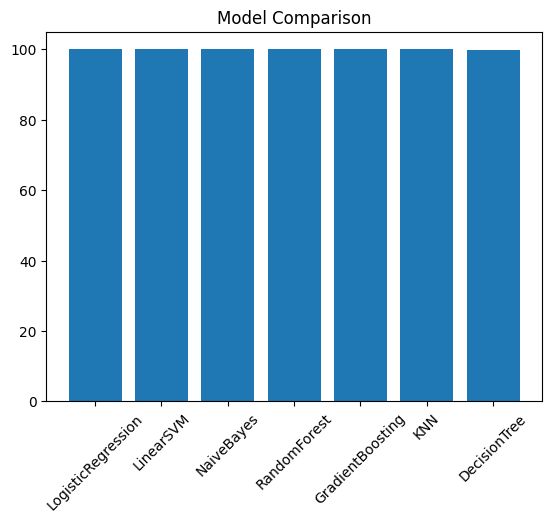

In [ ]:
plt.figure()
plt.bar(results_df['Model'],results_df['Accuracy'])
plt.xticks(rotation=45)
plt.title('Model Comparison')
plt.show()

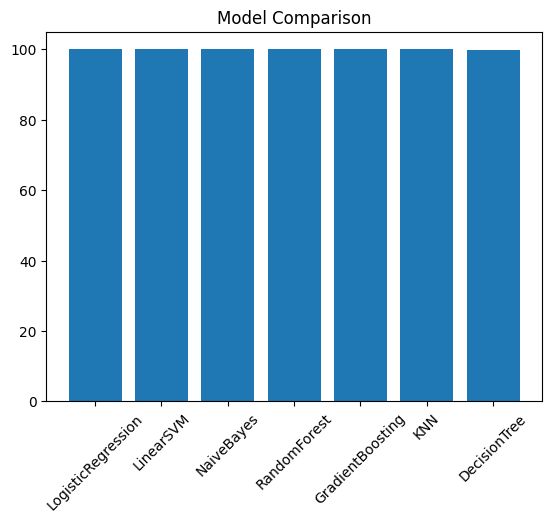

In [ ]:
plt.figure()
plt.bar(results_df['Model'],results_df['Accuracy'])
plt.xticks(rotation=45)
plt.title('Model Comparison')
plt.show()

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

final_pipeline = Pipeline([
('tfidf',TfidfVectorizer(max_features=10000,ngram_range=(1,2))),
('model',best_model)
])

final_pipeline.fit(X,y)
print('Best model trained:',best_model_name)

Best model trained: LogisticRegression


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X, y, cv=5)

print(scores)
print(scores.mean())

[1. 1. 1. 1. 1.]
1.0


In [ ]:
# Diagnostic code to check for issues
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Load the data
df = pd.read_csv('../data/processed/tickets_cleaned.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check if there are any duplicate texts
print("\nDuplicate clean_text entries:", df['clean_text'].duplicated().sum())

# Check class distribution
print("\nClass distribution:")
print(df['Issue_Category'].value_counts())

# Check if there are any patterns that could cause leakage
print("\nUnique values in clean_text:", df['clean_text'].nunique())
print("Total rows:", len(df))

# If unique values == total rows, each text is unique (which is good, not leakage)
if df['clean_text'].nunique() == len(df):
    print("✓ All texts are unique - no exact duplicates")
else:
    print("⚠ Found duplicate texts - check if they have same labels")

# Let's do a simple test with minimal features to see if we still get perfect scores
X = df['clean_text']
y = df['Issue_Category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Try with very limited features to force some errors
vectorizer = TfidfVectorizer(max_features=100)  # Limit to just 100 features
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train a simple model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)
pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, pred)
print(f"\nAccuracy with only 100 features: {acc:.4f}")

# Check if there's information in the text that makes this trivially classifiable
# Let's look at the most important words per class
feature_names = vectorizer.get_feature_names_out()
for i, class_name in enumerate(model.classes_):
    top_indices = np.argsort(model.coef_[i])[-5:]  # Top 5 coefficients
    top_features = [feature_names[idx] for idx in top_indices]
    print(f"Top features for {class_name}: {top_features}")

Dataset shape: (20000, 2)

First few rows:
                                          clean_text   Issue_Category
0  hours operation individual hi support headquar...  General Inquiry
1  data syncing card hi support application crash...        Technical
2  2fa issues question hi support upgrade enterpr...          Account
3  login failed let hi support dashboard loading ...        Technical
4  refund status attention hi support trying upda...          Billing

Duplicate clean_text entries: 0

Class distribution:
Issue_Category
Technical          5918
Billing            5036
Account            4081
General Inquiry    3925
Fraud              1040
Name: count, dtype: int64

Unique values in clean_text: 20000
Total rows: 20000
✓ All texts are unique - no exact duplicates

Accuracy with only 100 features: 0.9995
Top features for Account: ['email', '2fa', 'profile', 'upgrade', 'delete']
Top features for Billing: ['update', 'charge', 'invoice', 'refund', 'payment']
Top features for Fraud: ['su

In [ ]:
# Check if class names appear in text
for category in df['Issue_Category'].unique():
    category_lower = category.lower()
    contains = df['clean_text'].str.contains(category_lower).sum()
    print(f"Texts containing '{category_lower}': {contains}")

Texts containing 'general inquiry': 0
Texts containing 'technical': 0
Texts containing 'account': 3333
Texts containing 'billing': 0
Texts containing 'fraud': 0


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Create pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

# Perform cross-validation with shuffling
scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {scores}")
print(f"Mean CV accuracy: {scores.mean():.4f}")
print(f"Std CV accuracy: {scores.std():.4f}")

Cross-validation scores: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0000
Std CV accuracy: 0.0000


In [ ]:
# Check the relationship between words and classes
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Create a simple word frequency dataframe
vectorizer = CountVectorizer(max_features=50, stop_words='english')
X_word_counts = vectorizer.fit_transform(df['clean_text'])
word_features = vectorizer.get_feature_names_out()

# Create a dataframe with word frequencies per class
word_df = pd.DataFrame(X_word_counts.toarray(), columns=word_features)
word_df['category'] = y.values

# Calculate average word frequency per class
word_class_profile = word_df.groupby('category').mean()

print("Top words per class:")
for category in word_class_profile.index:
    top_words = word_class_profile.loc[category].sort_values(ascending=False).head(10)
    print(f"\n{category}:")
    print(top_words)

# Check if there's any overlap that would make classification difficult
print("\n" + "="*50)
print("Checking if classes have distinct vocabularies:")

# Get unique words that appear in each class
class_words = {}
for category in df['Issue_Category'].unique():
    class_texts = df[df['Issue_Category'] == category]['clean_text']
    vectorizer = CountVectorizer()
    vectorizer.fit(class_texts)
    class_words[category] = set(vectorizer.get_feature_names_out())
    print(f"{category}: {len(class_words[category])} unique words")

# Check overlap between classes
categories = list(class_words.keys())
for i in range(len(categories)):
    for j in range(i+1, len(categories)):
        cat1, cat2 = categories[i], categories[j]
        overlap = class_words[cat1] & class_words[cat2]
        print(f"\nOverlap between {cat1} and {cat2}: {len(overlap)} words")
        if len(overlap) < 10:  # If very little overlap
            print(f"  ⚠ Very little overlap - this makes classification easy!")
        # Show some overlapping words
        if len(overlap) > 0:
            print(f"  Examples: {list(overlap)[:5]}")

Top words per class:

Account:
support     1.004901
hi          1.000000
email       0.507964
account     0.499877
change      0.347464
reset       0.339378
password    0.339378
2fa         0.334232
upgrade     0.331046
delete      0.328351
Name: Account, dtype: float64

Billing:
support    1.006950
hi         1.000000
refund     0.344917
charge     0.339952
invoice    0.338761
update     0.324464
payment    0.315925
ago        0.180699
month      0.179508
send       0.178713
Name: Billing, dtype: float64

Fraud:
support       1.162500
hi            1.000000
account       0.527885
card          0.362500
login         0.325962
suspicious    0.310577
email         0.155769
issue         0.009615
month         0.008654
ago           0.008654
Name: Fraud, dtype: float64

General Inquiry:
support    1.172229
hi         1.000000
request    0.487643
hours      0.336306
team       0.333503
pricing    0.328662
demo       0.322548
time       0.008408
open       0.008153
month      0.007898
Name: